# PitWall — Model Training (Rolling Backtest)

**Input:** `data/features.csv`  
**Output:** `models/xgb_race_predictor_final.pkl`

Uses a proper rolling/expanding time-based split — no data leakage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded.")

Libraries loaded.


# 1. Load & Clean Data

In [2]:
raw = pd.read_csv("data/features.csv")

# ── fix dtypes ──────────────────────────────────────────────────────────────
# timedelta columns come back as strings from CSV — convert to total seconds
for col in ["q1_time", "q2_time", "q3_time", "pole_q3_time"]:
    if col in raw.columns:
        raw[col] = pd.to_timedelta(raw[col], errors="coerce").dt.total_seconds()

# encode booleans and categoricals
raw["had_grid_penalty"] = raw["had_grid_penalty"].astype(int)
raw["team_id_enc"]      = raw["team_id"].astype("category").cat.codes

# fill DNF target (no finish position = last place proxy)
raw["finish_position"]  = raw["finish_position"].fillna(20).astype(float)

print(f"Loaded {len(raw)} rows across seasons: {sorted(raw['season'].unique())}")
print(f"Dtypes problematic: {raw.select_dtypes(include='object').columns.tolist()}")

Loaded 3766 rows across seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Dtypes problematic: ['circuit_id', 'driver_id', 'driver_full_name', 'team_id', 'classified_status']


# 2. Define Feature Columns

Drop leaky columns (post-race info) and non-numeric columns.

In [3]:
DROP_COLS = [
    # post-race info — would leak the target
    "driver_full_name",
    "classified_status",
    "points",
    "finish_grid_delta",

    # raw timedeltas — replaced by quali_gap_to_pole
    "q1_time", "q2_time", "q3_time",
    "pole_q3_time",
    "best_quali_time", "pole_quali_time",  # may not exist, handled by errors='ignore'

    # intermediate computation columns
    "delta_i",

    # bool replaced by circuit_wet_race_frequency
    "race_had_rain",
]

TARGET = "finish_position"

# build feature list: everything numeric that isn't a label or target
FEATURE_COLS = [
    c for c in raw.columns
    if c not in DROP_COLS + [TARGET, "season", "round", "circuit_id", "driver_id", "team_id"]
] + ["team_id_enc"]

# deduplicate
FEATURE_COLS = list(dict.fromkeys(FEATURE_COLS))

# verify no object columns snuck in
X_check = raw[FEATURE_COLS]
bad_cols = X_check.select_dtypes(include="object").columns.tolist()
if bad_cols:
    print(f"WARNING — object columns in features (will cause XGBoost error): {bad_cols}")
else:
    print("All feature columns are numeric ✓")

print(f"\nFeature count: {len(FEATURE_COLS)}")
print("Features:", FEATURE_COLS)

All feature columns are numeric ✓

Feature count: 20
Features: ['grid_position', 'race_avg_air_temp', 'race_avg_track_temp', 'grid_penalty_places', 'had_grid_penalty', 'var_delta_i_norm', 'avg_team_finish_position', 'rolling_avg_finish_position', 'career_starts_at_circuit', 'avg_finish_at_circuit', 'avg_finish_grid_delta', 'teammate_wins', 'teammate_losses', 'teammate_win_pct', 'quali_gap_to_pole', 'team_avg_pace_delta', 'rolling_avg_pace_delta', 'pace_trend', 'circuit_wet_race_frequency', 'team_id_enc']


# 3. Rolling Backtest Evaluation

For each holdout season, train on all *prior* seasons only.
This is the correct way to evaluate a time-series prediction model — no shuffling, no leakage.

In [4]:
seasons     = sorted(raw["season"].unique())
# hold out the last two seasons for evaluation
# train on everything before each holdout season
eval_seasons = seasons[-2:]   # e.g. [2025, 2026]

print(f"All seasons:   {seasons}")
print(f"Eval seasons:  {eval_seasons}")
print()

backtest_results = []

for holdout in eval_seasons:
    train_df = raw[raw["season"] < holdout].copy()
    eval_df  = raw[raw["season"] == holdout].copy()

    if len(eval_df) == 0:
        print(f"  [SKIP] No data for holdout season {holdout}")
        continue

    X_train = train_df[FEATURE_COLS]
    y_train = train_df[TARGET]
    X_eval  = eval_df[FEATURE_COLS]
    y_eval  = eval_df[TARGET]

    model = XGBRegressor(
        objective        = "reg:squarederror",
        n_estimators     = 500,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.85,
        colsample_bytree = 0.85,
        min_child_weight = 3,
        reg_lambda       = 1.5,
        reg_alpha        = 0.1,
        random_state     = 42,
        n_jobs           = -1,
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_eval)

    race_metrics = []
    for _, race in eval_df[["season", "round"]].drop_duplicates().iterrows():
        mask   = (eval_df["season"] == race["season"]) & (eval_df["round"] == race["round"])
        actual = y_eval[mask].to_numpy()
        pred   = preds[mask]

        if len(actual) < 2:
            continue

        corr, _        = spearmanr(actual, pred)
        top10_actual   = set(eval_df.loc[mask, "driver_id"].to_numpy()[np.argsort(actual)[:10]])
        top10_pred     = set(eval_df.loc[mask, "driver_id"].to_numpy()[np.argsort(pred)[:10]])
        hit_rate       = len(top10_actual & top10_pred) / 10
        mae            = mean_absolute_error(actual, pred)

        race_metrics.append({"spearman": corr, "top10_hit": hit_rate, "mae": mae})

    backtest_results.append({
        "holdout_season":  holdout,
        "n_races":         len(race_metrics),
        "mean_spearman":   round(np.mean([m["spearman"]  for m in race_metrics]), 3),
        "mean_top10_hit":  round(np.mean([m["top10_hit"] for m in race_metrics]), 3),
        "mean_mae":        round(np.mean([m["mae"]       for m in race_metrics]), 3),
        "train_rows":      len(train_df),
    })
    print(f"Season {holdout} → Spearman: {backtest_results[-1]['mean_spearman']:.3f} | "
          f"Top-10 hit: {backtest_results[-1]['mean_top10_hit']:.3f} | "
          f"MAE: {backtest_results[-1]['mean_mae']:.3f}")

print()
print(pd.DataFrame(backtest_results).to_string(index=False))

All seasons:   [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Eval seasons:  [np.int64(2025), np.int64(2026)]

Season 2025 → Spearman: 0.874 | Top-10 hit: 0.875 | MAE: 1.970
Season 2026 → Spearman: 0.805 | Top-10 hit: 0.829 | MAE: 2.485

 holdout_season  n_races  mean_spearman  mean_top10_hit  mean_mae  train_rows
           2025       24          0.874           0.875     1.970        2979
           2026       14          0.805           0.829     2.485        3458


# 4. Feature Importance

From the most recent backtest model — tells us which features are actually driving predictions.

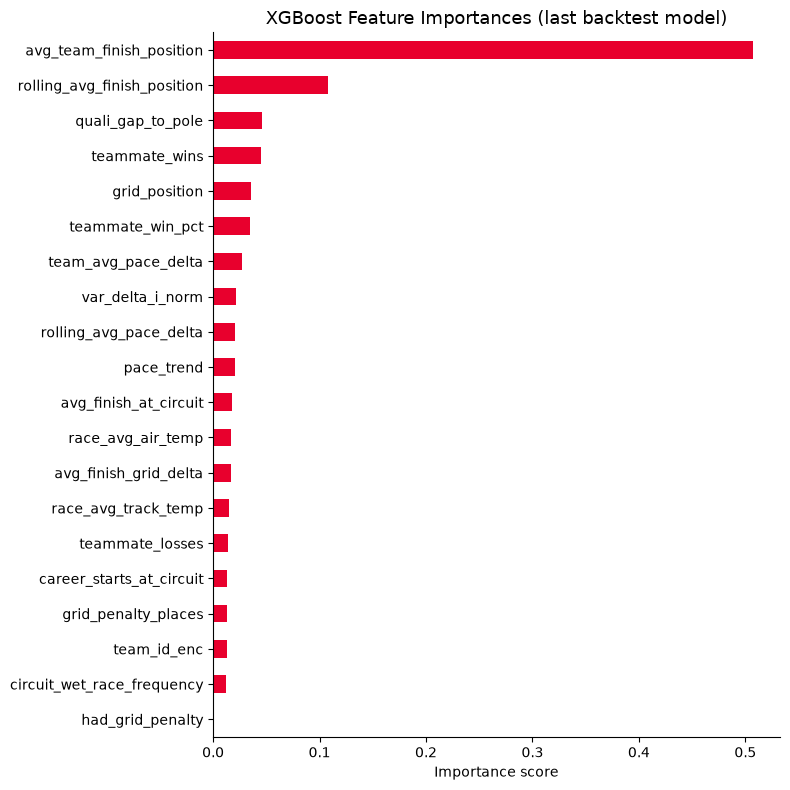


Top 5 features:
avg_team_finish_position       0.507190
rolling_avg_finish_position    0.108311
quali_gap_to_pole              0.046373
teammate_wins                  0.045462
grid_position                  0.035150
dtype: float32


In [5]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
importances.plot(kind="barh", ax=ax, color="#E8002D")
ax.set_title("XGBoost Feature Importances (last backtest model)", fontsize=13)
ax.set_xlabel("Importance score")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(importances.sort_values(ascending=False).head(5))

# 5. Train Final Model

Train on **all completed data** (2018 through last completed season).

2026 in-progress races are included as training data up to the latest completed round — the model learns from them too.

In [6]:
# determine the latest completed season
# if 2026 has races, include completed 2026 rounds in training
# exclude the current/upcoming race (that's what we're predicting)
latest_season = max(raw["season"])
print(f"Latest season in data: {latest_season}")
print(f"Seasons in data: {sorted(raw['season'].unique())}")

# train on everything — including completed 2026 rounds
# the predictor will use latest known features for upcoming races
final_train_df = raw.copy()

X_final = final_train_df[FEATURE_COLS]
y_final = final_train_df[TARGET]

final_model = XGBRegressor(
    objective        = "reg:squarederror",
    n_estimators     = 500,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.85,
    colsample_bytree = 0.85,
    min_child_weight = 3,
    reg_lambda       = 1.5,
    reg_alpha        = 0.1,
    random_state     = 42,
    n_jobs           = -1,
)

final_model.fit(X_final, y_final)

Path("models").mkdir(exist_ok=True)
joblib.dump(final_model, "models/xgb_race_predictor_final.pkl")
joblib.dump(FEATURE_COLS, "models/feature_cols.pkl")   # save so backend always uses same cols

print(f"\nFinal model trained on {len(final_train_df)} rows")
print(f"Saved → models/xgb_race_predictor_final.pkl")
print(f"Saved → models/feature_cols.pkl")

Latest season in data: 2026
Seasons in data: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Final model trained on 3766 rows
Saved → models/xgb_race_predictor_final.pkl
Saved → models/feature_cols.pkl


# 6. Predict Next Race

Fetches the next upcoming race from FastF1 automatically — no hardcoding needed.

In [7]:
import fastf1
from datetime import datetime, timezone

fastf1.Cache.enable_cache("./f1_cache")

# auto-detect next race
now      = datetime.now(timezone.utc)
schedule = fastf1.get_event_schedule(2026, include_testing=False)

next_event = None
for _, row in schedule.iterrows():
    event_date = row["EventDate"]
    if hasattr(event_date, "tzinfo") and event_date.tzinfo is None:
        event_date = event_date.tz_localize("UTC")
    if event_date > now:
        next_event = row
        break

if next_event is None:
    print("Season appears complete — using last event for demo")
    next_event = schedule.iloc[-1]

next_round   = int(next_event["RoundNumber"])
next_circuit = next_event["EventName"]
print(f"Predicting: {next_circuit} (Round {next_round}, 2026)")

Predicting: Azerbaijan Grand Prix (Round 15, 2026)


In [8]:
# build prediction rows: take each driver's most recent known state
latest_by_driver = (
    raw.sort_values(["season", "round"])
       .groupby("driver_id", as_index=False)
       .last()
)

ACTIVE_DRIVERS_2026 = [
    'ALB', 'ALO', 'ANT', 'BEA', 'BOR', 'BOT',
    'COL', 'GAS', 'HAD', 'HAM', 'HUL', 'LAW',
    'LEC', 'LIN', 'NOR', 'OCO', 'PER', 'PIA',
    'RUS', 'SAI', 'STR', 'VER'
]
latest_by_driver = latest_by_driver[
    latest_by_driver["driver_id"].isin(ACTIVE_DRIVERS_2026)
].copy()
print(f"Active drivers on grid: {len(latest_by_driver)}")

upcoming                = latest_by_driver.copy()
upcoming["season"]      = 2026
upcoming["round"]       = next_round
upcoming["circuit_id"]  = next_circuit
upcoming["grid_position"] = np.nan   # not known yet pre-qualifying

model_loaded   = joblib.load("models/xgb_race_predictor_final.pkl")
feature_cols   = joblib.load("models/feature_cols.pkl")

X_upcoming = upcoming[feature_cols].copy()
X_upcoming["had_grid_penalty"] = X_upcoming["had_grid_penalty"].astype(int)

preds = model_loaded.predict(X_upcoming)

upcoming["predicted_position"] = preds
upcoming["predicted_rank"]     = (
    upcoming["predicted_position"].rank(method="first").astype(int)
)

top10 = (
    upcoming[["driver_id", "driver_full_name", "team_id",
               "predicted_position", "predicted_rank"]]
    .sort_values("predicted_position")
    .head(10)
    .reset_index(drop=True)
)
top10.index = top10.index + 1

print(f"\n🏁 Predicted Top 10 — {next_circuit} 2026\n")
print(top10.to_string())

Active drivers on grid: 22

🏁 Predicted Top 10 — Azerbaijan Grand Prix 2026

   driver_id  driver_full_name          team_id  predicted_position  predicted_rank
1        ANT    Kimi Antonelli         Mercedes            4.916829               1
2        RUS    George Russell         Mercedes            6.402335               2
3        VER    Max Verstappen  Red Bull Racing            6.605173               3
4        NOR      Lando Norris          McLaren            7.952094               4
5        LAW       Liam Lawson  Red Bull Racing            8.381349               5
6        HAD      Isack Hadjar  Red Bull Racing            8.535561               6
7        GAS      Pierre Gasly           Alpine           10.218956               7
8        PIA     Oscar Piastri          McLaren           10.484117               8
9        LEC   Charles Leclerc          Ferrari           13.158418               9
10       COL  Franco Colapinto           Alpine           14.123434              10

# 7. SHAP Explainability

Explains why the model predicted each driver's position.

SHAP waterfall for predicted P1: Kimi Antonelli


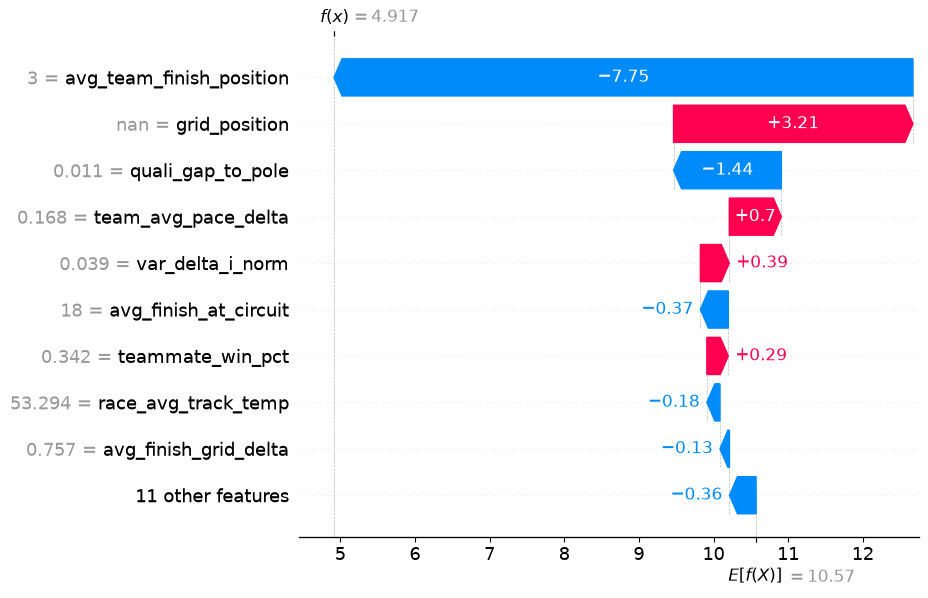

In [9]:
import shap

explainer  = shap.TreeExplainer(model_loaded)
shap_vals  = explainer.shap_values(X_upcoming)

# waterfall for predicted P1
p1_idx = upcoming["predicted_rank"].idxmin()
print(f"SHAP waterfall for predicted P1: {upcoming.loc[p1_idx, 'driver_full_name']}")

shap.waterfall_plot(
    shap.Explanation(
        values     = shap_vals[upcoming.index.get_loc(p1_idx)],
        base_values= explainer.expected_value,
        data       = X_upcoming.loc[p1_idx],
        feature_names=feature_cols,
    )
)

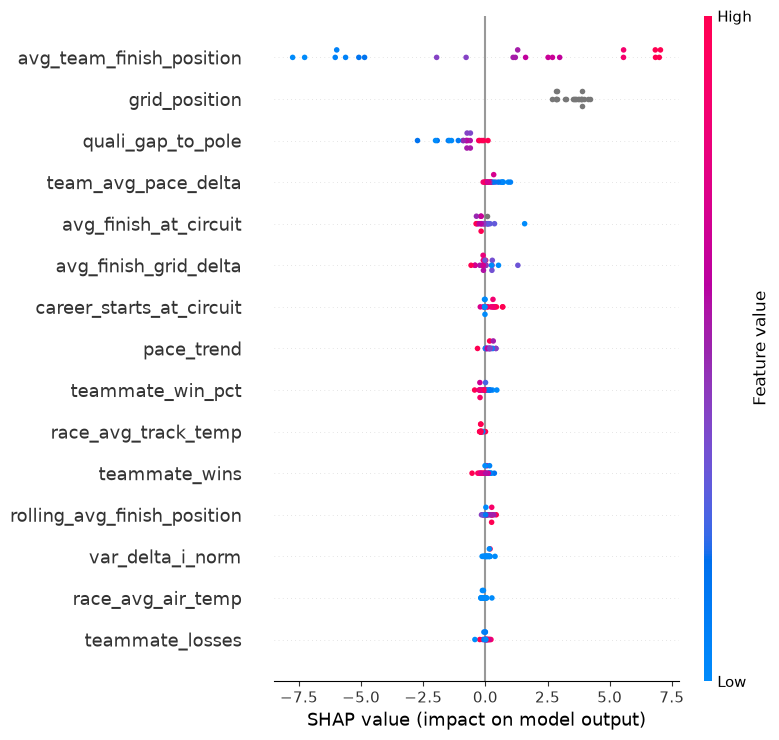

In [10]:
# summary plot across all drivers
shap.summary_plot(shap_vals, X_upcoming, feature_names=feature_cols, max_display=15)

In [11]:
drivers_2026 = raw[raw["season"] == 2026]["driver_id"].unique()
print(f"Drivers in 2026 data: {sorted(drivers_2026)}")
print(f"Count: {len(drivers_2026)}")

# also check teams
teams_2026 = raw[raw["season"] == 2026]["team_id"].unique()
print(f"\nTeams in 2026 data: {sorted(teams_2026)}")

Drivers in 2026 data: ['ALB', 'ALO', 'ANT', 'BEA', 'BOR', 'BOT', 'COL', 'GAS', 'HAD', 'HAM', 'HUL', 'LAW', 'LEC', 'LIN', 'NOR', 'OCO', 'PER', 'PIA', 'RUS', 'SAI', 'STR', 'TSU', 'VER']
Count: 23

Teams in 2026 data: ['Alpine', 'Aston Martin', 'Audi', 'Cadillac', 'Ferrari', 'Haas F1 Team', 'McLaren', 'Mercedes', 'Racing Bulls', 'Red Bull Racing', 'Williams']
